# Recomendaciones basadas en KNN para optimización de trabajos en HPC (Clúster Kabré de CeNAT/CONARE Costa Rica)

## Introducción


### 👥 Integrantes del grupo

|  Nombre | Carné |
|---|---|
| Daniel Garbanzo | 2022117129 |
| Luis Carlos Navarro Todd| 2022212158 |
| Ricardo Shum Estrada | 2017144193 |


A continuación se presenta el trabajo de un sistema de recomendaciones basado en KNN para optimización de trabajos Slurm en sistemas de computación de alto rendimiento (HPC), específicamente para el clúster Kabré de CeNAT/CONARE Costa Rica. El primer objetivo del trabajo es clasificar los trabajos del [dataset de trabajos de Kabré](https://raw.githubusercontent.com/DylanBC09/Project-1-CeNAT/refs/heads/main/dataset.csv) en completados y no completados, para después recomendar configuraciones de recursos (partición, QOS, tiempo, memoria_reservada) para nuevos trabajos basados en trabajos anteriores similares con el objetivo de que sean completados.

Se trabajará con la metodología CRISP-DM, que consta de las siguientes fases:
| Fase | Actividad en este trabajo |
|---|---|
| **1. Business Understanding** | Descripción del problema · Pregunta analítica · Criterio de éxito medible · Justificación del algoritmo |
| **2. Data Understanding** | Carga del dataset (URL pública) · Shape, tipos, estadísticos · ≥2 gráficas |
| **3. Data Preparation** | Análisis de NaN y outliers · Limpieza  · Manejo de faltantes · Creación de X y y (Feature Vector, Concepto #1) · Normalización de los datos (Concepto #2) |
| **4. Modeling** | Distancias L1 y L2 (Conceptos #3 y #4) · Implementación desde cero del algoritmo kNN (Combinaciones Lineales, Concepto #5) · Verificaciones numéricas intermedias|
| **5. Evaluation** | Cross-validation del hiperparámetro · Métricas calculadas manualmente · Comparación con baseline · Análisis de error · Visualización |
| **6. Deployment** | Interpretación en contexto del dataset · Limitaciones del modelo · Respuesta a la pregunta analítica |

---




## 1. Business Understanding

### Contexto

  Los clústeres de cómputo de alto rendimiento (HPC, *High Performance Computing*)
  son infraestructuras compartidas donde múltiples usuarios envían trabajos de cómputo intensivo. El gestor de colas **Slurm** (*Simple Linux Utility for Resource Management*) recibe estas solicitudes y las planifica según los recursos disponibles: CPUs, memoria, nodos y tiempo de ejecución.

  Cada trabajo enviado compite con otros por recursos limitados. El resultado final
  puedes ser:

  | Estado | Significado |
  |--------|-------------|
  | `COMPLETED` | El trabajo terminó exitosamente |
  | `FAILED` | El trabajo falló durante la ejecución |
  | `TIMEOUT` | El trabajo excedió su límite de tiempo configurado |
  | `CANCELLED` | El trabajo fue cancelado por el usuario o el sistema |

  ### El problema

  El dataset analizado corresponde a **46,744 trabajos** ejecutados en el clúster **Kabre** del Centro Nacional de Alta Tecnología (CeNAT) de Costa Rica durante 2024, distribuidos en particiones como `andalan`, `dribe`, `kura` y `nukwa`, entre otras.

  La distribución de resultados revela un problema significativo:

  | Estado | Trabajos | Porcentaje |
  |--------|----------|------------|
  | `FAILED` | 24,335 | 52.1% |
  | `COMPLETED` | 16,782 | 35.9% |
  | `CANCELLED` | 4,001 | 8.6% |
  | `TIMEOUT` | 1,621 | 3.5% |

  **Solo el 35.9% de los trabajos se completan exitosamente.** Esto representa un
  costo
  significativo: tiempo de investigador desperdiciado, recursos computacionales
  consumidos
  sin resultado, y retrasos en proyectos científicos.

  ### Objetivo

  Este proyecto aborda el problema en dos etapas:

  1. **Predicción**: Predecir si un trabajo (*basado en propiedades como: CPUs solicitados, memoria, partición, límite de tiempo, prioridad,
     momento de envío*) será completado exitosamente (`COMPLETED`) o
  no.

  2. **Recomendación**: Para los trabajos predichos como no exitosos, generar
     **contrafactuales** — sugerencias concretas y accionables sobre cómo modificar
     la configuración del trabajo para aumentar su probabilidad de éxito.

  ### Pregunta analítica

*"¿Es posible predecir con precisión si un trabajo en el clúster Kabré se completará exitosamente, y si no, qué cambios específicos en su configuración podrían aumentar esa probabilidad?"*

  La idea es que el sistema actúe como un asistente de diagnóstico previo al envío. Por ejemplo:

  > *"Tu trabajo tiene una probabilidad del 12% de completarse. Si reduces el límite
  > de tiempo de 7 días a 2 días y cambias la partición de `nu-long` a `nukwa`, la
  > probabilidad sube al 68%."*

  Esto permite al investigador tomar decisiones informadas antes de comprometer
  recursos,
  reduciendo el ciclo de prueba y error que hoy es la norma en el uso de clústeres
  HPC.

  ### Criterio de éxito
  El éxito se medirá en dos niveles:
  1. **Predicción**: Un modelo de clasificación binaria con una precisión (accuracy) de al menos el 90% en un conjunto de prueba separado.
  2. **Recomendación**: Contrafactuales que, al ser aplicados a trabajos no exitosos, aumenten su probabilidad de éxito en al menos un 30% según el modelo predictivo.

  ### Enfoque técnico

  El clasificador se implementa con **k-Nearest Neighbours (kNN) desde cero**,
  eligiendo este algoritmo por su interpretabilidad geométrica natural: la vecindad de un punto en el espacio de features define directamente cuáles trabajos similares
  fueron exitosos, lo que facilita la construcción de los contrafactuales sin
  necesidad de aproximaciones adicionales. Además, ya ha sido explorado en el contexto de Kabré.

  ---

# 2. Data Understanding

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 4)
sns.set_theme(style='whitegrid', palette='muted')

# Carga del dataset (separador pipe)
df = pd.read_csv('new_dataset.csv', sep='|', parse_dates=['Submit'])

new_df = pd.read_csv('new_dataset.csv', sep='|', parse_dates=['Submit'])

print(f"Shape: {df.shape}")
display(df.head())

Shape: (229466, 12)


,ConsumedEnergyRaw,CPUTimeRAW,ReqCPUS,ReqMem,ReqNodes,ResvCPURAW,Submit,TimelimitRaw,Partition,Priority,QOS,State
0,3800474.0,4147584,1,100Mc,1,345743,2024-06-25 14:03:31,1440,nukwa-wide,7046,normal,TIMEOUT
1,0.0,4147968,1,100Mc,1,172857,2024-06-25 14:03:34,1440,nukwa-wide,7046,normal,TIMEOUT
2,3774906.0,4147392,1,100Mc,1,432175,2024-06-25 14:03:37,1440,nukwa-wide,7046,normal,TIMEOUT
3,3782559.0,4147536,1,100Mc,1,259290,2024-06-25 14:03:47,1440,nukwa-wide,7046,normal,TIMEOUT
4,3723128.0,4088688,1,100Mc,1,518590,2024-06-25 14:03:56,1440,nukwa-wide,7046,normal,COMPLETED


### TimelimitRaw tiene valores numéricos, entonces vamos a convertirlos todos en string


In [68]:
df["TimelimitRaw"] = df["TimelimitRaw"].astype(str)

In [69]:
print("Valores únicos en TimelimitRaw:")
display(df['TimelimitRaw'].unique())

Valores únicos en TimelimitRaw:


<StringArray>
[ '1440',  '4200',    '60', '44640',   '300',  '4320', '10080', '10140',
   '480',    '40',
 ...
   '230', '28800',   '110',    '85',  '1740',  '1620', '61440', '30000',
  '2850',  '1410']
Length: 174, dtype: str

In [70]:
df.dtypes

ConsumedEnergyRaw           float64
CPUTimeRAW                    int64
ReqCPUS                       int64
ReqMem                          str
ReqNodes                      int64
ResvCPURAW                    int64
Submit               datetime64[us]
TimelimitRaw                    str
Partition                       str
Priority                      int64
QOS                             str
State                           str
dtype: object

In [71]:
### 2.2 Tipos de datos y estadísticos descriptivos
print("=== Tipos de datos ===")
print(df.dtypes)
print(f"\n=== Estadísticos (variables numéricas) ===")
display(df.describe())

=== Tipos de datos ===
ConsumedEnergyRaw           float64
CPUTimeRAW                    int64
ReqCPUS                       int64
ReqMem                          str
ReqNodes                      int64
ResvCPURAW                    int64
Submit               datetime64[us]
TimelimitRaw                    str
Partition                       str
Priority                      int64
QOS                             str
State                           str
dtype: object

=== Estadísticos (variables numéricas) ===


,ConsumedEnergyRaw,CPUTimeRAW,ReqCPUS,ReqNodes,ResvCPURAW,Submit,Priority
count,2.170720e+05,2.294660e+05,229466.000000,229466.000000,2.294660e+05,229466,229466.000000
mean,4.769963e+05,2.052787e+05,10.734383,1.033526,8.092876e+05,2025-09-27 02:04:15.083036,3833.536315
min,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000e+00,2024-06-25 14:03:31,0.000000
25%,1.820000e+02,1.200000e+01,1.000000,1.000000,0.000000e+00,2025-06-10 19:18:22,1994.000000
50%,1.037000e+03,4.000000e+02,1.000000,1.000000,1.000000e+00,2026-01-14 03:16:39,2718.000000
75%,1.622625e+04,3.020000e+03,16.000000,1.000000,2.400000e+01,2026-02-02 23:02:53,4355.000000
max,8.045518e+08,6.856732e+08,1280.000000,18.000000,4.294967e+09,2026-06-08 23:56:09,16293.000000
std,5.461249e+06,4.459506e+06,39.738871,0.388295,5.251509e+07,NaN,2904.043496


### 2.3 Valores nulos y duplicados

In [72]:
nulls = df.isnull().sum()
nulls_pct = nulls / len(df) * 100
null_df = pd.DataFrame({'Nulos': nulls, '% Nulos': nulls_pct}).query('Nulos > 0')

if null_df.empty:
    print("No hay valores nulos en el dataset.")
else:
    display(null_df)

dups = df.duplicated().sum()
print(f"\nFilas duplicadas: {dups} ({dups/len(df)*100:.2f}%)")

,Nulos,% Nulos
ConsumedEnergyRaw,12394,5.401236



Filas duplicadas: 11258 (4.91%)


### 2.4 Variable objetivo: distribución de `State`

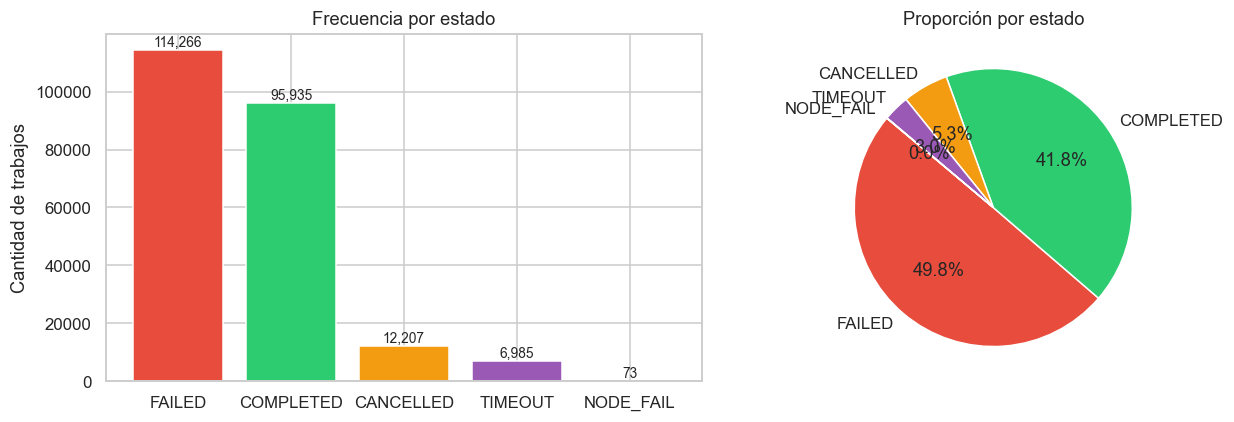


Tabla resumen:


,Trabajos,%
State,,
FAILED,114266,49.80
COMPLETED,95935,41.81
CANCELLED,12207,5.32
TIMEOUT,6985,3.04
NODE_FAIL,73,0.03


In [73]:
df['State'] = df['State'].str.split().str[0]  # Solo la primera palabra (ej. "COMPLETED" de "COMPLETED (0)")
state_counts = df['State'].value_counts()
state_pct = state_counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
colors = {'COMPLETED': '#2ecc71', 'FAILED': '#e74c3c', 'CANCELLED': '#f39c12', 'TIMEOUT': '#9b59b6'}
bar_colors = [colors.get(s, '#95a5a6') for s in state_counts.index]
axes[0].bar(state_counts.index, state_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Frecuencia por estado')
axes[0].set_ylabel('Cantidad de trabajos')
for bar, val in zip(axes[0].patches, state_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Pie
axes[1].pie(state_pct.values, labels=state_pct.index,
            autopct='%1.1f%%', colors=bar_colors, startangle=140)
axes[1].set_title('Proporción por estado')

plt.tight_layout()
plt.show()

print("\nTabla resumen:")
display(pd.DataFrame({'Trabajos': state_counts, '%': state_pct.round(2)}))

### 2.5 Variables categóricas: `Partition` y `QOS`

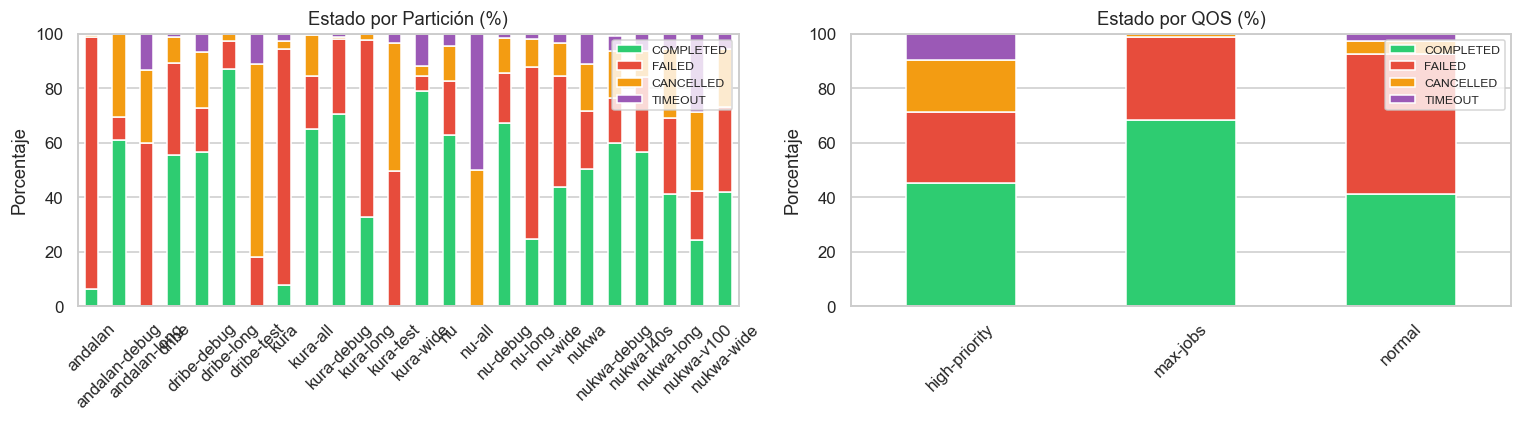

Trabajos por Partición:


,Trabajos
Partition,
kura,71755
dribe-long,39971
dribe,22114
kura-long,17661
andalan,16764
kura-wide,16236
nukwa-l40s,11690
nukwa,6643
nukwa-long,5940



Trabajos por QOS:


,Trabajos
QOS,
normal,214466
high-priority,12815
max-jobs,2185


In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Partición
part_state = df.groupby(['Partition', 'State']).size().unstack(fill_value=0)
part_state_pct = part_state.div(part_state.sum(axis=1), axis=0) * 100
part_state_pct[['COMPLETED', 'FAILED', 'CANCELLED', 'TIMEOUT']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'])
axes[0].set_title('Estado por Partición (%)')
axes[0].set_ylabel('Porcentaje')
axes[0].set_xlabel('')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

# QOS
qos_state = df.groupby(['QOS', 'State']).size().unstack(fill_value=0)
qos_state_pct = qos_state.div(qos_state.sum(axis=1), axis=0) * 100
qos_state_pct[['COMPLETED', 'FAILED', 'CANCELLED', 'TIMEOUT']].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'])
axes[1].set_title('Estado por QOS (%)')
axes[1].set_ylabel('Porcentaje')
axes[1].set_xlabel('')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Trabajos por Partición:")
display(df['Partition'].value_counts().to_frame('Trabajos'))
print("\nTrabajos por QOS:")
display(df['QOS'].value_counts().to_frame('Trabajos'))

### 2.6 Variables numéricas: distribuciones y outliers

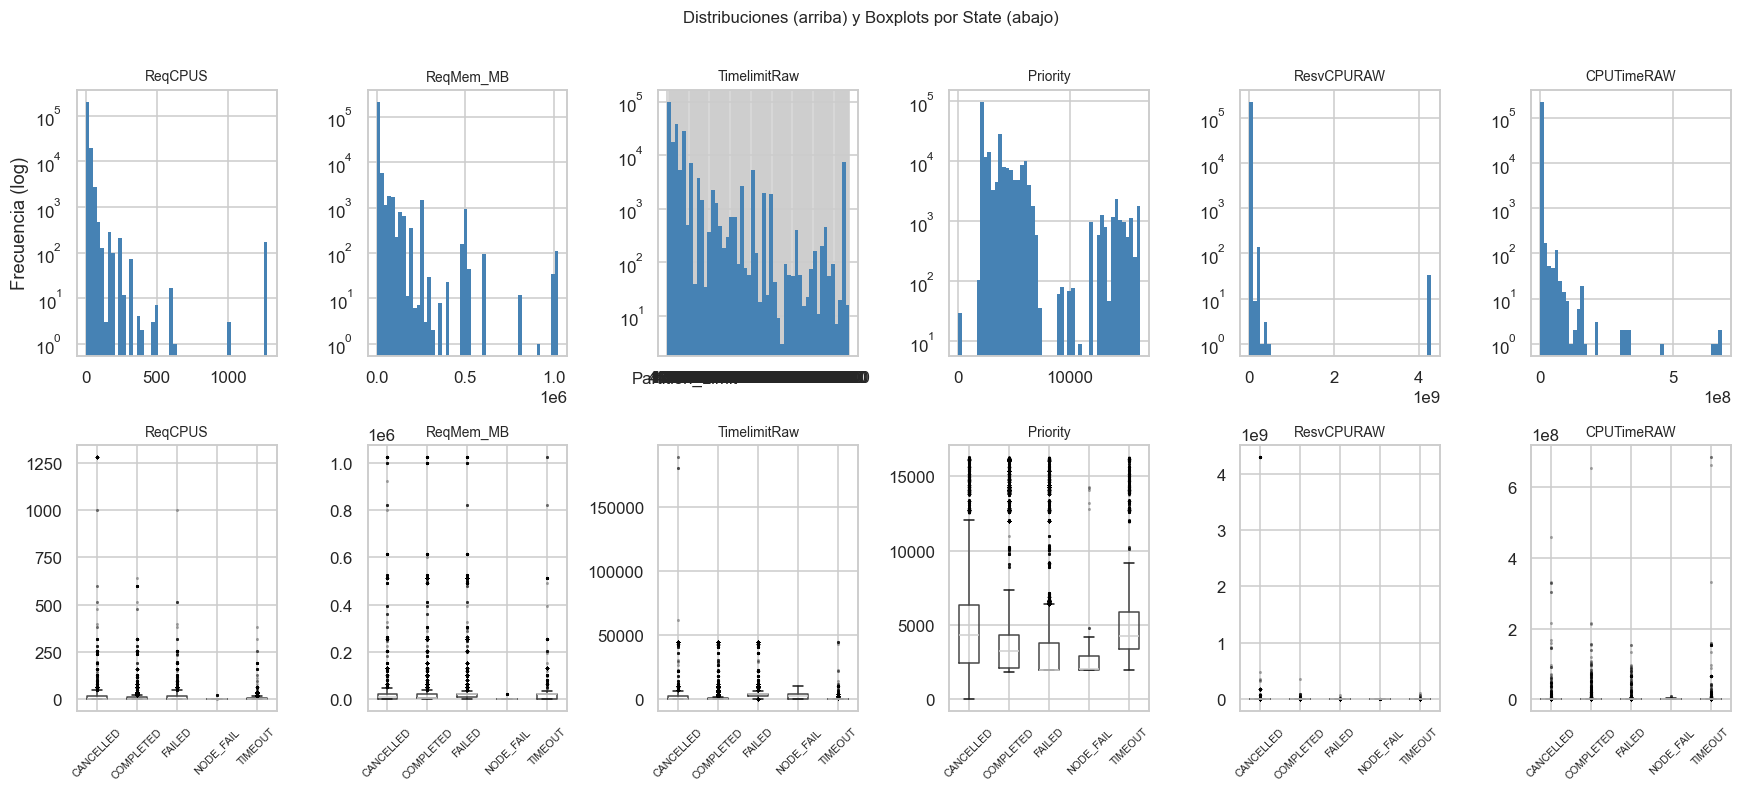

In [75]:
# Parsear ReqMem: convierte '100Mc' -> 100 MB/core, '4Gn' -> 4096 MB/nodo, etc.
def parse_reqmem(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.endswith('Mc'):
        return float(val[:-2])          # MB por core
    elif val.endswith('Mn'):
        return float(val[:-2])          # MB por nodo
    elif val.endswith('Gc'):
        return float(val[:-2]) * 1024   # GB por core -> MB
    elif val.endswith('Gn'):
        return float(val[:-2]) * 1024   # GB por nodo -> MB
    else:
        try:
            return float(val)
        except:
            return np.nan

df['ReqMem_MB'] = df['ReqMem'].apply(parse_reqmem)

num_cols = ['ReqCPUS', 'ReqMem_MB', 'TimelimitRaw', 'Priority', 'ResvCPURAW', 'CPUTimeRAW']

fig, axes = plt.subplots(2, len(num_cols), figsize=(16, 7))

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    # Histograma (log scale)
    axes[0, i].hist(data, bins=50, color='steelblue', edgecolor='none', log=True)
    axes[0, i].set_title(col, fontsize=9)
    axes[0, i].set_xlabel('')
    axes[0, i].set_ylabel('Frecuencia (log)' if i == 0 else '')

    # Boxplot por estado
    numeric_col = pd.to_numeric(df[col], errors='coerce')
    plot_df = df.loc[numeric_col.notna(), ['State']].copy()
    plot_df[col] = numeric_col[numeric_col.notna()]
    plot_df.boxplot(column=col, by='State', ax=axes[1, i],
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    axes[1, i].set_title(col, fontsize=9)
    axes[1, i].set_xlabel('')
    axes[1, i].tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('')
fig.text(0.5, 1.01, 'Distribuciones (arriba) y Boxplots por State (abajo)', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [76]:
# Parece haber data no numérica en TimelimitRaw
print("Valores únicos en TimelimitRaw:")
display(df['TimelimitRaw'].unique())

Valores únicos en TimelimitRaw:


<StringArray>
[ '1440',  '4200',    '60', '44640',   '300',  '4320', '10080', '10140',
   '480',    '40',
 ...
   '230', '28800',   '110',    '85',  '1740',  '1620', '61440', '30000',
  '2850',  '1410']
Length: 174, dtype: str

### 2.7 Análisis temporal: envíos por mes y hora del día

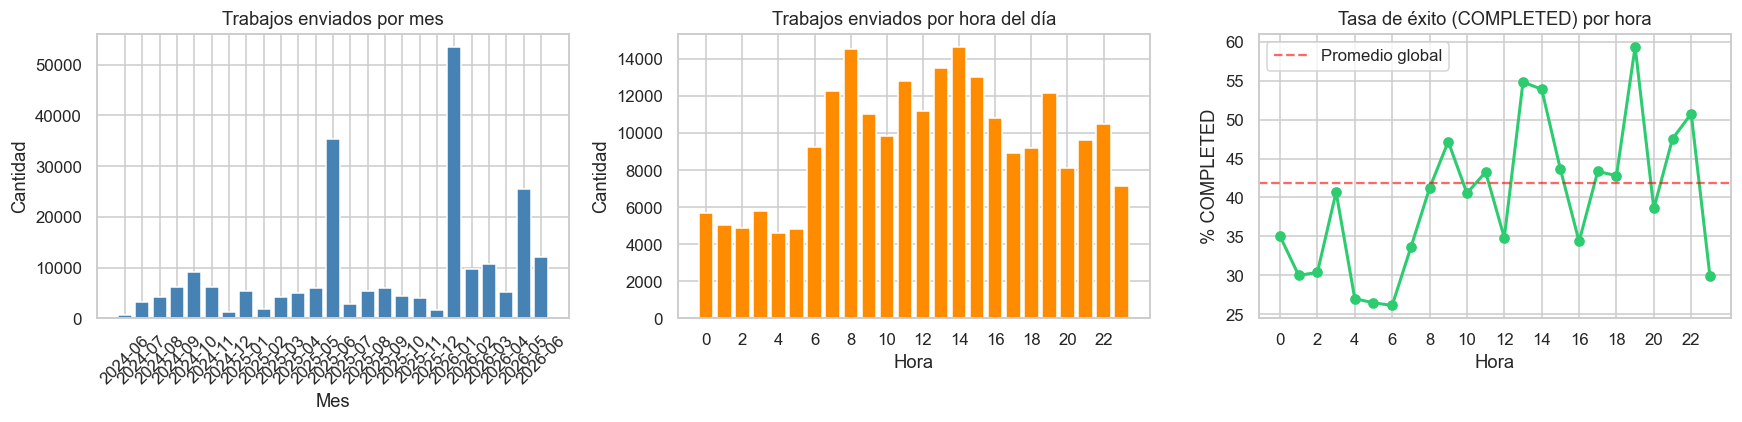

In [77]:
df['submit_month'] = df['Submit'].dt.to_period('M')
df['submit_hour'] = df['Submit'].dt.hour
df['submit_dow'] = df['Submit'].dt.day_name()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Trabajos por mes
month_counts = df.groupby('submit_month').size()
axes[0].bar(month_counts.index.astype(str), month_counts.values, color='steelblue')
axes[0].set_title('Trabajos enviados por mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)

# Trabajos por hora del día
hour_counts = df.groupby('submit_hour').size()
axes[1].bar(hour_counts.index, hour_counts.values, color='darkorange')
axes[1].set_title('Trabajos enviados por hora del día')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Cantidad')
axes[1].set_xticks(range(0, 24, 2))

# Tasa de completado por hora del día
completed_by_hour = df[df['State'] == 'COMPLETED'].groupby('submit_hour').size()
total_by_hour = df.groupby('submit_hour').size()
success_rate = (completed_by_hour / total_by_hour * 100).fillna(0)
axes[2].plot(success_rate.index, success_rate.values, marker='o', color='#2ecc71', linewidth=2)
axes[2].set_title('Tasa de éxito (COMPLETED) por hora')
axes[2].set_xlabel('Hora')
axes[2].set_ylabel('% COMPLETED')
axes[2].set_xticks(range(0, 24, 2))
axes[2].axhline(df['State'].eq('COMPLETED').mean() * 100, color='red',
                linestyle='--', alpha=0.6, label='Promedio global')
axes[2].legend()

plt.tight_layout()
plt.show()

### 2.8 Resumen de hallazgos del EDA

| Hallazgo | Detalle |
|---|---|
| **Desbalance de clases** | Solo el ~36% de trabajos son `COMPLETED`; el ~52% son `FAILED`. Requiere manejo de desbalance en el modelo. |
| **Partición crítica** | Las tasas de éxito varían mucho por partición — algunas tienen >60% de éxito, otras casi 0%. La partición es feature clave. Además se deberían unir por tipo (Andalán, Nukwa, Nu, Kurá ,Dribe) |
| **Tasa de éxito por hora** | Los trabajos suelen tener una tasa de éxito más alta durante ciertas horas del día. |
| **Nulos** | Algunas columnas numéricas tienen valores nulos que deben ser manejados (imputación o eliminación). |
| **TimelimitRaw con valores no numéricos** | Aparecen valores no numéricos en la columna `TimelimitRaw` que deben ser tratados. |

# 3. Data Preparation

### 3.1 Limpieza de datos

#### 3.1.1 Nulos y Duplicados


In [78]:
# Remover nulos y duplicados
print(f"Shape original: {df.shape}")
print(f"Nulos totales originales: {df.isnull().sum().sum()}")
print(f"Duplicados originales: {df.duplicated().sum()}")

df = df.dropna().drop_duplicates().reset_index(drop=True)

print("\nDespués de limpieza:")
print(f"Shape: {df.shape}")
print(f"Nulos totales: {df.isnull().sum().sum()}")
print(f"Duplicados: {df.duplicated().sum()}")


Shape original: (229466, 16)
Nulos totales originales: 12516
Duplicados originales: 11258

Después de limpieza:
Shape: (207050, 16)
Nulos totales: 0
Duplicados: 0


#### 3.1.2 Particiones Estandarizadas

Se unirán las particiones por tipo para reducir la cardinalidad y mejorar la generalización del modelo. Por ejemplo, `andalan`, `andalan-long` y `andalan-debug` se agruparán como `Andalán`. Esto también ayuda a mitigar el problema de particiones con muy pocos ejemplos.

In [79]:
df['PartitionGroup'] = df['Partition'].str.split('-').str[0].str.capitalize()  # Unificar por tipo (Andalán, Nukwa, Nu, Kurá ,Dribe)
print("Particiones estandarizadas:")
display(df['PartitionGroup'].value_counts().to_frame('Trabajos'))

Particiones estandarizadas:


,Trabajos
PartitionGroup,
Kura,99602
Dribe,58439
Nukwa,23892
Andalan,16229
Nu,8888


#### 3.1.3 Manejo de valores no numéricos en `TimelimitRaw`

In [80]:
# Parsear TimelimitRaw según partición:
# - Si es numérico, se conserva.
# - Si viene como "Partition_Limit" (u otro no numérico), se reemplaza por esto:
# nukwa	GPU	1	24 horas
# nukwa-debug	GPU	1	4 horas
# nukwa-wide	GPU	2	24 horas
# nukwa-long	GPU	1	48 horas
# dribe-long	Xeon	1	744 horas
# dribe	Xeon	1	72 horas
# dribe-debug	Xeon	1	8 horas
# kurá-debug	Xeon	1	8 horas
# kurá-wide	Xeon	4	24 horas
# kurá	Xeon	1	72 horas
# kurá-long	Xeon	1	168 horas
# Andalan y Nu igual que Kurá
def parse_timelimit(val, partition):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.isdigit():
        return float(val)
    mapping = {
        'nukwa': 24 * 3600,
        'nukwa-debug': 4 * 3600,
        'nukwa-wide': 24 * 3600,
        'nukwa-long': 48 * 3600,
        'dribe-long': 744 * 3600,
        'dribe': 72 * 3600,
        'dribe-debug': 8 * 3600,
        'kurá-debug': 8 * 3600,
        'kurá-wide': 24 * 3600,
        'kurá': 72 * 3600,
        'kura': 72 * 3600,
        'kurá-long': 168 * 3600,
        'andalan': 72 * 3600,
        'andalan-debug': 8 * 3600,
        'andalan-long': 168 * 3600,
        'nu': 72 * 3600,
        'nu-debug': 8 * 3600,
        'nu-long': 168 * 3600
    }
    for key in mapping:
        if key in partition.lower():
            return mapping[key]
    return np.nan

df['TimelimitSec'] = df.apply(lambda row: parse_timelimit(row['TimelimitRaw'], row['Partition']), axis=1)
print("TimelimitRaw parseado:")
display(df[['TimelimitRaw', 'Partition', 'TimelimitSec']].head(10))

TimelimitRaw parseado:


,TimelimitRaw,Partition,TimelimitSec
0,1440,nukwa-wide,1440.0
1,1440,nukwa-wide,1440.0
2,1440,nukwa-wide,1440.0
3,1440,nukwa-wide,1440.0
4,1440,nukwa-wide,1440.0
5,4200,andalan,4200.0
6,4200,andalan,4200.0
7,1440,kura,1440.0
8,44640,dribe-long,44640.0
9,1440,kura,1440.0


### 3.2 Correlaciones entre variables numéricas

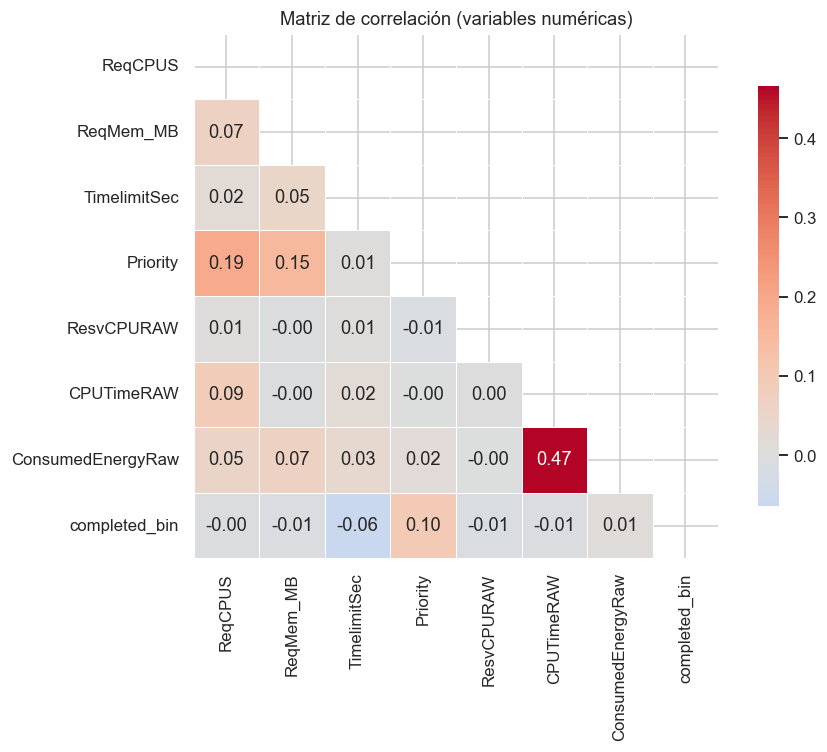


Correlación con 'completed_bin':


Priority             0.096691
TimelimitSec        -0.064057
ResvCPURAW          -0.011195
CPUTimeRAW          -0.009893
ReqMem_MB           -0.008687
ConsumedEnergyRaw    0.008662
ReqCPUS             -0.002794
Name: completed_bin, dtype: float64

In [81]:
# Variable objetivo binaria para correlación
df['completed_bin'] = (df['State'] == 'COMPLETED').astype(int)

corr_cols = ['ReqCPUS', 'ReqMem_MB', 'TimelimitSec', 'Priority',
             'ResvCPURAW', 'CPUTimeRAW', 'ConsumedEnergyRaw', 'completed_bin']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.show()

# Correlaciones con el target ordenadas
print("\nCorrelación con 'completed_bin':")
display(corr_matrix['completed_bin'].drop('completed_bin').sort_values(key=abs, ascending=False))

### 3.3 Análisis de outliers con IQR

In [82]:
outlier_cols = ['ReqCPUS', 'ReqMem_MB', 'TimelimitSec', 'Priority', 'CPUTimeRAW']

rows = []
for col in outlier_cols:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    lb = max(lb, 0)  # No permitir límites negativos
    n_out = ((data < lb) | (data > ub)).sum()
    rows.append({'Columna': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                 'Límite inferior': lb, 'Límite superior': ub,
                 'Outliers': n_out, '% Outliers': round(n_out / len(data) * 100, 2)})

outlier_df = pd.DataFrame(rows).set_index('Columna')
display(outlier_df)

plt.tight_layout()
plt.show()

,Q1,Q3,IQR,Límite inferior,Límite superior,Outliers,% Outliers
Columna,,,,,,,
ReqCPUS,1.0,10.0,9.0,0,23.5,31485,15.21
ReqMem_MB,2000.0,20000.0,18000.0,0,47000.0,8128,3.93
TimelimitSec,240.0,4200.0,3960.0,0,10140.0,5757,2.78
Priority,1994.0,4290.0,2296.0,0,7734.0,10531,5.09
CPUTimeRAW,20.0,2124.0,2104.0,0,5280.0,39941,19.29


<Figure size 1100x440 with 0 Axes>

Se pueden observar varios outliers, sin embargo, son datos que se encuentran dentro de lo esperado para un clúster HPC, por lo que se mantendrán para preservar la variabilidad real del dataset. 

### 3.4 One-hot encoding de variables categóricas

In [83]:
def one_hot(value: str, categories: list[str]) -> list[float]:
    return [1.0 if value.strip() == c else 0.0 for c in categories]

### 3.5 Creación de matrices de características (X) y etiquetas (y) (Concepto #1)

En la siguiente celda se muestra la creación de las matrices de características (X) y etiquetas (y) a partir del dataset limpio. La matriz `X` contiene las features numéricas y las variables categóricas codificadas, mientras que la matriz `y` contiene la variable objetivo binaria que indica si el trabajo fue completado exitosamente o no. Esto es fundamental para el entrenamiento del modelo kNN, que requiere una representación numérica de los datos. Los datos categóricos se codifican utilizando one-hot encoding, lo que permite al modelo interpretar cada categoría como una dimensión separada en el espacio de características.

In [84]:
PARTITION_GROUPS = df['PartitionGroup'].unique().tolist()
QOS_CATEGORIES = df['QOS'].unique().tolist()

def build_features(row: dict) -> list[float] | None:
    """
    Returns a feature vector or None if the row has critical missing values.

    Feature vector layout (14 dims):
      [0]  ReqCPUS
      [1]  ReqMem_MB
      [2]  ReqNodes
      [3]  ResvCPURAW
      [4]  TimelimitSec
      [5]  Priority
      [6]  submit_hour
      [7]  submit_dow
      [8..12]  one-hot Partition  (5 categories)
      [13,14]  one-hot QOS        (2 categories)
    """
    try:
        req_cpus = float(row["ReqCPUS"])
        req_mem = float(row["ReqMem_MB"])
        req_nodes = float(row["ReqNodes"])
        resv_cpu = float(row["ResvCPURAW"])
        timelimit = float(row["TimelimitSec"])
        priority = float(row["Priority"])
        hour, dow = float(row["submit_hour"]), float(row["Submit"].dayofweek)
    except (ValueError, KeyError):
        print(f"Fila con datos faltantes o no numéricos: {row.get('JobID', 'N/A')}")
        return None

    vec = [
        req_cpus,
        req_mem,
        req_nodes,
        resv_cpu,
        timelimit,
        priority,
        float(hour),
        float(dow),
        *one_hot(row["PartitionGroup"], PARTITION_GROUPS),
        *one_hot(row["QOS"], QOS_CATEGORIES),
    ]
    return vec

In [85]:
X_raw, y_raw = [], df['State'].apply(lambda s: 1 if s.strip() == 'COMPLETED' else 0).tolist()

for _, row in df.iterrows():
    features = build_features(row)
    if features is not None:
        X_raw.append(features)

print(f"Total muestras con features: {len(X_raw)}")

Total muestras con features: 207050


### 3.6 División del Dataset

In [86]:
def split_list(lst, test_ratio: float = 0.2) -> tuple:
    cut = int(len(lst) * test_ratio)
    return lst[cut:], lst[:cut]   # train, test


def stratified_split(
    X: list[list[float]],
    y: list[int],
    test_ratio: float = 0.2,
    seed: int = 42,
) -> tuple:
    """Returns X_train, X_test, y_train, y_test."""
    import random
    rng = random.Random(seed)

    idx_pos = [i for i, label in enumerate(y) if label == 1]
    idx_neg = [i for i, label in enumerate(y) if label == 0]

    rng.shuffle(idx_pos)
    rng.shuffle(idx_neg)

    train_pos, test_pos = split_list(idx_pos, test_ratio)
    train_neg, test_neg = split_list(idx_neg, test_ratio)

    train_idx = train_pos + train_neg
    test_idx = test_pos + test_neg
    rng.shuffle(train_idx)
    rng.shuffle(test_idx)

    X_train = [X[i] for i in train_idx]
    y_train = [y[i] for i in train_idx]
    X_test = [X[i] for i in test_idx]
    y_test = [y[i] for i in test_idx]

    return X_train, X_test, y_train, y_test


In [87]:
X_train, X_test, y_train, y_test = stratified_split(X_raw, y_raw, test_ratio=0.2, seed=42)

### 3.7 Normalización de Datos (Concepto #2)

A continuación se muestra la función de normalización min-max implementada desde cero, que escala cada feature al rango [0, 1] utilizando la fórmula:
$$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

Esto se hace para asegurar que todas las features numéricas estén en la misma escala, lo cual es crucial para el funcionamiento adecuado del algoritmo kNN, ya que se basa en la distancia entre puntos en el espacio de características.

In [88]:
class MinMaxScaler:
    def __init__(self):
        self.mins: list[float] = []
        self.maxs: list[float] = []

    def fit(self, X: list[list[float]]) -> "MinMaxScaler":
        n_feat = len(X[0])
        self.mins = [min(row[j] for row in X) for j in range(n_feat)]
        self.maxs = [max(row[j] for row in X) for j in range(n_feat)]
        return self

    def transform(self, X: list[list[float]]) -> list[list[float]]:
        scaled = []
        for row in X:
            new_row = []
            for j, val in enumerate(row):
                denom = self.maxs[j] - self.mins[j]
                new_row.append(
                    (val - self.mins[j]) / denom if denom > 0 else 0.0)
            scaled.append(new_row)
        return scaled

    def inverse_transform_one(self, row: list[float]) -> list[float]:
        """Recover original-scale values from a single scaled row."""
        return [
            val * (self.maxs[j] - self.mins[j]) + self.mins[j]
            for j, val in enumerate(row)
        ]

    def fit_transform(self, X: list[list[float]]) -> list[list[float]]:
        return self.fit(X).transform(X)

In [89]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4. Modeling

### 4.1 Implementación de distancias L1 (Manhattan) y L2 (Euclidiana) (Conceptos #3 y #4)

En el siguiente código se muestra la implementación desde cero de las funciones para calcular las distancias L1 (Manhattan) y L2 (Euclidiana) entre un punto de consulta y un conjunto de puntos en la matriz de características. Estas funciones se utilizan para determinar la similitud entre trabajos en el espacio de características, lo que es fundamental para el algoritmo kNN. La distancia Manhattan se calcula como la suma de las diferencias absolutas entre las coordenadas, mientras que la distancia Euclidiana se calcula como la raíz cuadrada de la suma de las diferencias al cuadrado. Estas implementaciones permiten al modelo kNN identificar los vecinos más cercanos de un trabajo dado, lo que a su vez facilita la predicción de su estado (completado o no) y la generación de contrafactuales para mejorar su probabilidad de éxito. La distancia Manhattan (L1) se puede ver también como el costo de moverse en la cuadrícula de características.

In [90]:
# Distancias por batch (vectorizadas) L2 y L1
def _euclidean_batch(query: np.ndarray, X_train: np.ndarray) -> np.ndarray:
    """||query - x||₂  for every row x in X_train."""
    diff = X_train - query          # (n, d)
    return np.sqrt((diff * diff).sum(axis=1))

def _manhattan_batch(query: np.ndarray, X_train: np.ndarray) -> np.ndarray:
    """Σ|query_i - x_i|  for every row x in X_train."""
    return np.abs(X_train - query).sum(axis=1)

## 4.2 Implementación del algoritmo kNN desde cero

In [91]:
from collections import Counter

class KNNClassifier:
    """
    k-Nearest Neighbours classifier.

    Parameters
    ----------
    k : int
        Number of neighbours to use.
    metric : str
        Distance metric: "euclidean", "manhattan".
    weighted : bool
        If True, neighbours vote weighted by 1/distance.
        If False, plain majority vote.
    """

    def __init__(
        self,
        k: int = 5,
        metric: str = "euclidean",
        weighted: bool = False,
    ):
        if metric not in ("euclidean", "manhattan"):
            raise ValueError(f"Unknown metric '{metric}'.")
        self.k = k
        self.metric = metric
        self.weighted = weighted
        self._X: np.ndarray | None = None
        self._y: np.ndarray | None = None

    # ------------------------------------------------------------------ #
    def fit(self, X, y) -> "KNNClassifier":
        """Store training data as numpy arrays (lazy learning)."""
        self._X = np.asarray(X, dtype=np.float64)
        self._y = np.asarray(y, dtype=np.int32)
        return self

    # ------------------------------------------------------------------ #
    def _distances(self, query: np.ndarray) -> np.ndarray:
        if self.metric == "euclidean":
            return _euclidean_batch(query, self._X)
        if self.metric == "manhattan":
            return _manhattan_batch(query, self._X)
        raise NotImplementedError("Metric not implemented yet.")

    def _get_neighbours(self, query: np.ndarray):
        """
        Returns (distances, labels) arrays for the k nearest neighbours,
        sorted ascending by distance.
        """
        dists = self._distances(query)
        # argpartition gives the k smallest indices (unsorted), then sort them
        k_idx = np.argpartition(dists, self.k)[: self.k]
        k_idx = k_idx[np.argsort(dists[k_idx])]
        return dists[k_idx], self._y[k_idx]

    # ------------------------------------------------------------------ #
    def predict_one(self, query) -> int:
        q = np.asarray(query, dtype=np.float64)
        dists, labels = self._get_neighbours(q)
        if self.weighted:
            weights = 1.0 / (dists + 1e-9)
            votes: dict[int, float] = {}
            for w, lbl in zip(weights, labels):
                votes[int(lbl)] = votes.get(int(lbl), 0.0) + float(w)
            return max(votes, key=votes.__getitem__)
        else:
            return int(Counter(labels.tolist()).most_common(1)[0][0])

    def predict(self, X) -> list[int]:
        X_arr = np.asarray(X, dtype=np.float64)
        return [self.predict_one(row) for row in X_arr]

    # ------------------------------------------------------------------ #
    def predict_proba_one(self, query) -> dict[int, float]:
        """Returns {class: probability} for the query point."""
        q = np.asarray(query, dtype=np.float64)
        dists, labels = self._get_neighbours(q)
        if self.weighted:
            weights = 1.0 / (dists + 1e-9)
            votes: dict[int, float] = {}
            for w, lbl in zip(weights, labels):
                votes[int(lbl)] = votes.get(int(lbl), 0.0) + float(w)
            total = sum(votes.values())
            return {cls: v / total for cls, v in votes.items()}
        else:
            total = len(labels)
            counts: dict[int, int] = {}
            for lbl in labels:
                counts[int(lbl)] = counts.get(int(lbl), 0) + 1
            return {cls: cnt / total for cls, cnt in counts.items()}

    def predict_proba(self, X) -> list[dict[int, float]]:
        X_arr = np.asarray(X, dtype=np.float64)
        return [self.predict_proba_one(row) for row in X_arr]

    # ------------------------------------------------------------------ #
    def get_neighbours_for(self, query) -> list[tuple[float, int]]:
        """Returns k nearest (distance, label) pairs sorted ascending."""
        q = np.asarray(query, dtype=np.float64)
        dists, labels = self._get_neighbours(q)
        return list(zip(dists.tolist(), labels.tolist()))

#### 4.2.1 Concepto #5: Combinaciones Lineales

Como se puede observar, el algoritmo kNN tiene una opción de ponderación de vecinos según su peso. Esto aplica una combinación lineal de las etiquetas de los vecinos, donde cada vecino contribuye a la predicción final con un peso inversamente proporcional a su distancia al punto de consulta. Esto significa que los vecinos más cercanos tienen una mayor influencia en la predicción que los vecinos más lejanos, lo que puede mejorar la precisión del modelo al considerar la relevancia de cada vecino en lugar de tratarlos a todos por igual.

$$ v_i = \frac{1}{d_i + \epsilon}$$

Donde $ v_i $ es el peso del vecino `i`, $d_i$ es la distancia del vecino `i` al punto de consulta, y ε es una pequeña constante para evitar división por cero y underflow (1e-9).

### 4.3 Fit y predict del modelo kNN

In [92]:
kNN = KNNClassifier(k=5, metric="euclidean", weighted=False)
kNN.fit(X_train, y_train)
kNN_predictions = kNN.predict(X_test)

In [93]:
print(f"Predicciones kNN (primeros 20): {kNN_predictions[:20]}")
print(f"Labels reales (primeros 20)   : {y_test[:20]}")

Predicciones kNN (primeros 20): [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0]
Labels reales (primeros 20)   : [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0]


## 4.3 Explanability y generación de contrafactuales

### 4.3.1 Vector Decoding para Interpretación de Feature Vectors

In [94]:
_DOW_NAMES = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

def decode_vector(
    scaled_row: list[float],
    feature_names: list[str],
    scaler: "MinMaxScaler",
) -> dict:
    """
    Convert a scaled feature vector to a human-readable dict.

    Numeric features are inverse-transformed and shown with units.
    One-hot groups (partition_*, qos_*) are decoded to the active category name.

    Returns: {display_name: formatted_string}
    """
    raw = scaler.inverse_transform_one(scaled_row)
    # Check for NaNs in the raw values (indicating missing data)
    if any(np.isnan(raw)):
        
        print("Warning: Raw feature vector contains NaN values. Decoding may be incomplete.")
        print(raw)
        print(scaled_row)
        raw = [0.0 if np.isnan(v) else v for v in raw]  # Replace NaNs with 0 for decoding
    result = {}

    # --- Numeric features ------------------------------------------------- #
    numeric_fmt = {
        "ReqCPUS": lambda v: f"{int(round(v))} CPUs",
        "ReqMem_MB": lambda v: f"{int(round(v))} MB",
        "ReqNodes": lambda v: f"{int(round(v))} nodos",
        "ResvCPURAW": lambda v: f"{int(round(v))} CPU-s reservados",
        "TimelimitSec": lambda v: f"{int(round(v))} segundos",
        "Priority": lambda v: f"{int(round(v))}",
        "submit_hour": lambda v: f"{int(round(v)):02d}:00 h",
        "submit_dow": lambda v: _DOW_NAMES[min(6, max(0, int(round(v))))],
    }
    for name, fmt in numeric_fmt.items():
        if name in feature_names:
            idx = feature_names.index(name)
            result[name] = fmt(raw[idx])

    # --- One-hot: Partition ------------------------------------------------ #
    part_indices = [i for i, n in enumerate(
        feature_names) if PARTITION_GROUPS]
    if part_indices:
        best_i = max(part_indices, key=lambda i: scaled_row[i])
        result["Partition"] = feature_names[best_i]

    # --- One-hot: QOS ------------------------------------------------------ #
    qos_indices = [i for i, n in enumerate(
        feature_names) if QOS_CATEGORIES]
    if qos_indices:
        best_i = max(qos_indices, key=lambda i: scaled_row[i])
        result["QOS"] = feature_names[best_i]

    return result


### 4.3.2 Reason Codes

In [95]:
def reason_codes(
    query: list[float],
    clf: KNNClassifier,
    feature_names: list[str],
    target_class: int = 1,
) -> list[tuple[str, float]]:
    """
    Contribución de cada feature a la distancia entre el query
    y los k vecinos más cercanos de target_class.

    Contribución = fracción de la distancia euclidiana cuadrada
    aportada por cada feature (promedio sobre los k vecinos).
    Rango [0, 1], suma ≈ 1.

    Features con valor alto están 'alejando' el query de target_class.
    """
    q = np.asarray(query, dtype=np.float64)

    # ── Obtener vectores del training set de target_class ──────────────
    mask        = clf._y == target_class
    target_vecs = clf._X[mask]          # shape (n_target, d)

    if len(target_vecs) == 0:
        return [(name, 0.0) for name in feature_names]

    # ── k vecinos más cercanos de target_class ─────────────────────────
    k       = min(clf.k, len(target_vecs))
    diffs   = target_vecs - q                                    # (n_target, d)
    sq_dist = (diffs ** 2).sum(axis=1)                          # (n_target,)
    k_idx   = np.argpartition(sq_dist, k - 1)[:k]
    nearest = diffs[k_idx]                                       # (k, d)  ya son diferencias

    # ── Contribución por feature ───────────────────────────────────────
    # Para cada vecino: fracción de distancia² aportada por cada feature
    sq_diffs    = nearest ** 2                                   # (k, d)
    total_sq    = sq_diffs.sum(axis=1, keepdims=True)           # (k, 1)

    # Evitar división por cero (query == vecino exacto)
    total_sq    = np.where(total_sq == 0, 1.0, total_sq)

    fractions   = sq_diffs / total_sq                           # (k, d) en [0,1]
    mean_frac   = fractions.mean(axis=0)                        # (d,)

    contributions = list(zip(feature_names, mean_frac.tolist()))
    contributions.sort(key=lambda t: -t[1])
    return contributions

In [96]:
def explain_reason_codes(
    query: list[float],
    clf: KNNClassifier,
    feature_names: list[str],
    scaler,
    target_class: int = 1,
    top_n: int = 5,
) -> None:
    """Imprime los top-N reason codes con valores reales decodificados."""
    rc = reason_codes(query, clf, feature_names, target_class)
    decoded = decode_vector(query, feature_names, scaler)

    print(f"Top {top_n} features que alejan el job de clase {target_class}:\n")
    print(f"  {'Feature':<16} {'Contribución':>12}  {'Valor actual'}")
    print("  " + "─" * 48)
    for name, contrib in rc[:top_n]:
        val = decoded.get(name, "?")
        bar = "█" * int(contrib * 40)
        print(f"  {name:<16} {contrib:>11.1%}  {val}  {bar}")

    print(f"\n  Suma top-{top_n}: {sum(c for _, c in rc[:top_n]):.1%} de la distancia total")

### 4.3.3 Counterfactuals para trabajos no exitosos

In [97]:
def generate_counterfactual(
    query: list[float],
    clf: KNNClassifier,
    feature_names: list[str],
    scaler,
    target_class: int = 1,
    step_size: float = 0.1,
    max_iterations: int = 500,
) -> dict:
    MUTABLES = {"ReqCPUS", "ReqMem_MB", "ReqNodes", "TimelimitSec", "Priority", 
           *PARTITION_GROUPS, *QOS_CATEGORIES}
    mut_idx = [feature_names.index(name) for name in MUTABLES]

    # ── FIX 2: escalar query antes de operar en espacio del kNN ──────────
    query_array = np.array(query).reshape(1, -1)
    query_scaled = scaler.transform(query_array)[0]
    # ─────────────────────────────────────────────────────────────────────

    # FIX: usar query_scaled para reason_codes y todo lo que sigue
    rc = reason_codes(query_scaled, clf, feature_names, target_class)
    rc_map = {name: score for name, score in rc}
    mut_idx_sorted = sorted(
        mut_idx,
        key=lambda i: -rc_map.get(feature_names[i], 0.0),
    )

    current = list(query_scaled)  # trabajamos siempre en espacio escalado
    original_proba = clf.predict_proba_one(query_scaled).get(target_class, 0.0)

    # ── FIX 1: verificar ANTES de iterar si ya es target_class ───────────
    already_target = clf.predict_one(current) == target_class
    if already_target:
        # Job ya predicho como target — no es útil para counterfactual
        # Devolvemos found=False para que el caller lo descarte
        orig_decoded = decode_vector(list(query_scaled), feature_names, scaler)
        return {
            "found":            False,
            "already_target":   True,   # flag nuevo para distinguir del caso "no convergió"
            "counterfactual":   current,
            "changes":          [],
            "proba_original":   original_proba,
            "proba_cf":         original_proba,
            "original_decoded": orig_decoded,
            "cf_decoded":       orig_decoded,
        }
    # ─────────────────────────────────────────────────────────────────────

    step_sizes = [0.20, 0.10, 0.05, 0.02]

    for iteration in range(max_iterations):
        if clf.predict_one(current) == target_class:
            break

        best_gain = -1.0
        best_candidate = None
        current_proba = clf.predict_proba_one(current).get(target_class, 0.0)

        for j in mut_idx_sorted:
            for s in step_sizes:
                for direction in (+s, -s):
                    candidate = list(current)
                    candidate[j] = max(0.0, min(1.0, candidate[j] + direction))
                    proba = clf.predict_proba_one(candidate).get(target_class, 0.0)
                    gain = proba - current_proba
                    if gain > best_gain:
                        best_gain = gain
                        best_candidate = candidate

        if best_candidate is None or best_gain <= 1e-6:
            break
        current = best_candidate

    found = clf.predict_one(current) == target_class
    cf_proba = clf.predict_proba_one(current).get(target_class, 0.0)

    orig_decoded = decode_vector(list(query_scaled), feature_names, scaler)
    cf_decoded   = decode_vector(current,            feature_names, scaler)

    ONE_HOT_GROUPS = {
        "PartitionGroup": PARTITION_GROUPS,
        "QOS":            QOS_CATEGORIES,
    }

    changes = []
    reported_groups: set[str] = set()

    for j, fname in enumerate(feature_names):
        delta = current[j] - query_scaled[j]  # comparar en mismo espacio
        if abs(delta) < 1e-6:
            continue

        if fname in PARTITION_GROUPS or fname in QOS_CATEGORIES:
            for group_name, members in ONE_HOT_GROUPS.items():
                if fname in members and group_name not in reported_groups:
                    orig_val = orig_decoded.get(group_name, "?")
                    cf_val   = cf_decoded.get(group_name, "?")
                    if orig_val != cf_val:
                        changes.append({
                            "feature":       group_name,
                            "original_real": orig_val,
                            "cf_real":       cf_val,
                            "delta_scaled":  None,
                        })
                        reported_groups.add(group_name)
            continue

        orig_val = orig_decoded.get(fname, f"{query_scaled[j]:.3f}")
        cf_val   = cf_decoded.get(fname,   f"{current[j]:.3f}")
        changes.append({
            "feature":       fname,
            "original_real": orig_val,
            "cf_real":       cf_val,
            "delta_scaled":  delta,
        })

    return {
        "found":            found,
        "already_target":   False,
        "counterfactual":   current,
        "changes":          changes,
        "proba_original":   original_proba,
        "proba_cf":         cf_proba,
        "original_decoded": orig_decoded,
        "cf_decoded":       cf_decoded,
    }

In [98]:
def explain(result: dict) -> str:
    lines = []
    status = "ENCONTRADO" if result["found"] else "NO encontrado (aproximado)"
    lines.append(f"Contrafactual: {status}")
    lines.append(
        f"P(COMPLETED): {result['proba_original']:.2%} → {result['proba_cf']:.2%}"
    )

    if result["changes"]:
        lines.append("\nCambios sugeridos:")
        for ch in result["changes"]:
            delta = ch["delta_scaled"]
            if delta is None:
                arrow = "↔"   # categorical change
            elif delta > 0:
                arrow = "▲"
            else:
                arrow = "▼"
            lines.append(
                f"  {arrow} {ch['feature']:<14s}  "
                f"{ch['original_real']}  →  {ch['cf_real']}"
            )
    else:
        lines.append("Sin cambios necesarios (ya clasificado como COMPLETED).")

    return "\n".join(lines)


## 5. Evaluation

### 5.1 Métricas de evaluación

In [99]:
def confusion_matrix(y_true: list[int], y_pred: list[int]) -> dict:
    tp = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 1)
    tn = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 0)
    fp = sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0)
    return {"TP": tp, "TN": tn, "FP": fp, "FN": fn}


def accuracy(y_true, y_pred) -> float:
    return sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)


def precision(cm: dict) -> float:
    denom = cm["TP"] + cm["FP"]
    return cm["TP"] / denom if denom > 0 else 0.0


def recall(cm: dict) -> float:
    denom = cm["TP"] + cm["FN"]
    return cm["TP"] / denom if denom > 0 else 0.0


def f1_score(cm: dict) -> float:
    p, r = precision(cm), recall(cm)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0


def roc_auc(y_true: list[int], y_scores: list[float]) -> float:
    """
    Compute AUC-ROC using the trapezoidal rule.
    y_scores: probability of the positive class (class=1).
    """
    # Sort by descending score
    pairs = sorted(zip(y_scores, y_true), key=lambda t: -t[0])

    n_pos = sum(y_true)
    n_neg = len(y_true) - n_pos
    if n_pos == 0 or n_neg == 0:
        return 0.0

    tpr_list, fpr_list = [0.0], [0.0]
    tp = fp = 0

    for _, label in pairs:
        if label == 1:
            tp += 1
        else:
            fp += 1
        tpr_list.append(tp / n_pos)
        fpr_list.append(fp / n_neg)

    # Trapezoidal AUC
    auc = 0.0
    for i in range(1, len(fpr_list)):
        auc += (fpr_list[i] - fpr_list[i - 1]) * \
            (tpr_list[i] + tpr_list[i - 1]) / 2
    return auc

def rmse(y_true: list[float], y_pred: list[float]) -> float:
    mse = sum((t - p) ** 2 for t, p in zip(y_true, y_pred)) / len(y_true)
    return mse ** 0.5

### 5.2 Cross-validation del hiperparámetro k

In [100]:
def cross_val(
    X,
    y,
    k_values: list[int],
    n_folds: int = 5,
    metric: str = "euclidean",
) -> tuple[dict[int, float], dict[int, float], dict[int, float], dict[int, float]]:
    """
    Stratified k-fold cross-validation.
    Returns {k: mean_accuracy} for each k in k_values.
    """
    import random
    rng = random.Random(0)

    y_list = list(y) if not isinstance(y, list) else y

    idx_pos = [i for i, lbl in enumerate(y_list) if lbl == 1]
    idx_neg = [i for i, lbl in enumerate(y_list) if lbl == 0]
    rng.shuffle(idx_pos)
    rng.shuffle(idx_neg)

    def make_folds(indices):
        size = len(indices) // n_folds
        return [indices[i * size: (i + 1) * size] for i in range(n_folds)]

    folds_pos = make_folds(idx_pos)
    folds_neg = make_folds(idx_neg)
    folds = [folds_pos[i] + folds_neg[i] for i in range(n_folds)]

    X_arr = np.asarray(X, dtype=np.float64)
    y_arr = np.asarray(y_list, dtype=np.int32)

    acc_results: dict[int, float] = {}
    rmse_results: dict[int, float] = {}
    f1_results: dict[int, float] = {}
    auc_results: dict[int, float] = {}

    for k in k_values:
        fold_accs = []
        rmse_vals = []
        f1_vals = []
        auc_vals = []
        for fold_i in range(n_folds):
            test_idx = folds[fold_i]
            train_idx = [idx for j, f in enumerate(
                folds) if j != fold_i for idx in f]

            clf = KNNClassifier(k=k, metric=metric)
            clf.fit(X_arr[train_idx], y_arr[train_idx])
            preds = clf.predict(X_arr[test_idx])
            acc = np.mean(np.array(preds) == y_arr[test_idx])
            fold_accs.append(float(acc))
            rmse_vals.append(float(rmse(y_arr[test_idx], preds)))
            auc_vals.append(float(roc_auc(y_arr[test_idx], preds)))
            f1_vals.append(float(f1_score(confusion_matrix(y_arr[test_idx], preds))))


        acc_results[k] = sum(fold_accs) / len(fold_accs)
        rmse_results[k] = sum(rmse_vals) / len(rmse_vals)
        f1_results[k] = sum(f1_vals) / len(f1_vals)
        auc_results[k] = sum(auc_vals) / len(auc_vals)

        print(f"  k={k:3d}  CV accuracy={acc_results[k]:.4f}, RMSE={rmse_results[k]:.4f}, F1={f1_results[k]:.4f}, AUC={auc_results[k]:.4f}")

    return acc_results, rmse_results, f1_results, auc_results

In [101]:
acc_results, rmse_results, f1_results, auc_results = cross_val(X_train, y_train, k_values=[3, 5, 10, 25, 50, 100], n_folds=10, metric="euclidean")

  k=  3  CV accuracy=0.9000, RMSE=0.3161, F1=0.8914, AUC=0.9899
  k=  5  CV accuracy=0.8956, RMSE=0.3231, F1=0.8871, AUC=0.9891
  k= 10  CV accuracy=0.8936, RMSE=0.3262, F1=0.8857, AUC=0.9887
  k= 25  CV accuracy=0.8779, RMSE=0.3494, F1=0.8705, AUC=0.9856
  k= 50  CV accuracy=0.8712, RMSE=0.3589, F1=0.8647, AUC=0.9844
  k=100  CV accuracy=0.8626, RMSE=0.3707, F1=0.8575, AUC=0.9831


### 5.3 Análisis de error y visualización

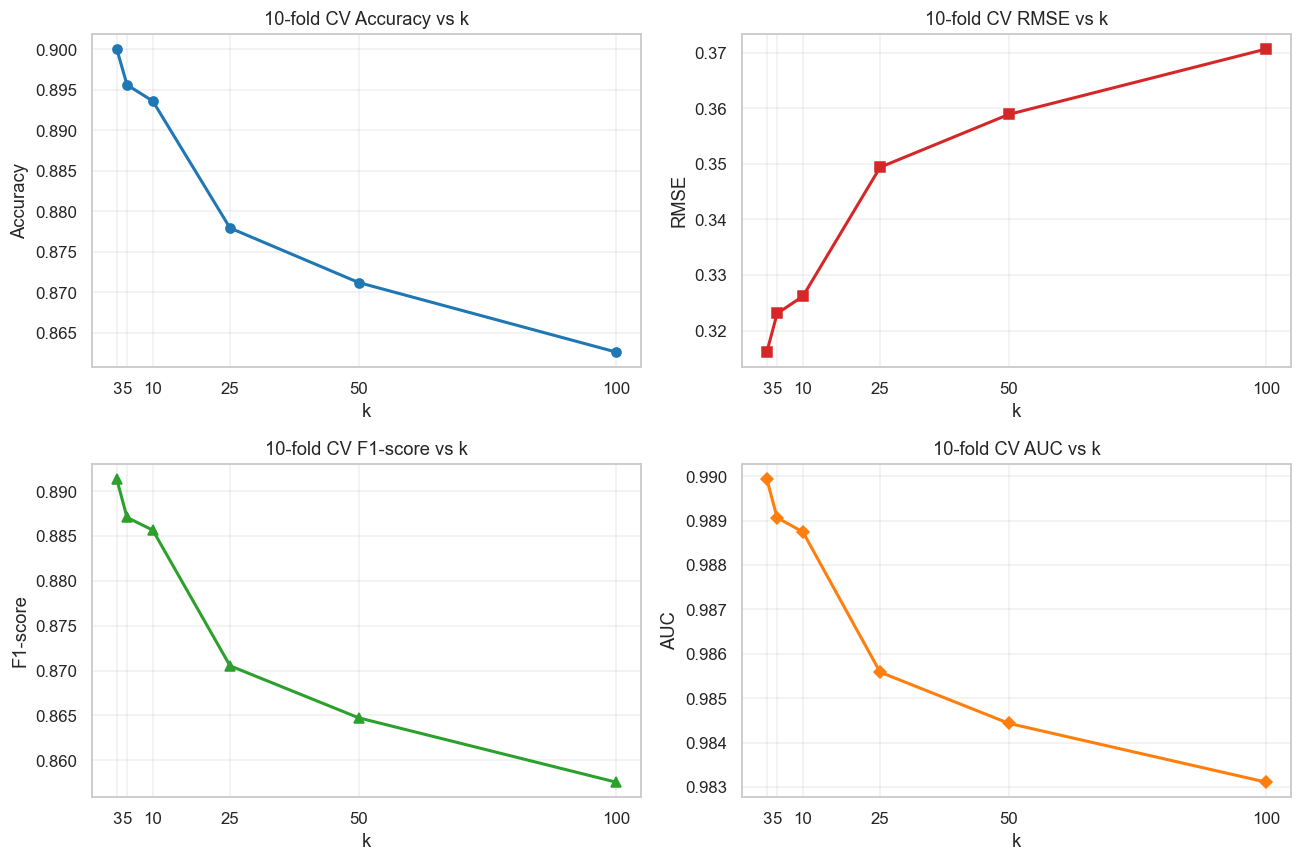

In [102]:
# Plot de Accuracy y RMSE (10-fold CV) vs k
k_values = sorted(acc_results.keys())
acc_values = [acc_results[k] for k in k_values]
rmse_values = [rmse_results[k] for k in k_values]
f1_values = [f1_results[k] for k in k_values]
auc_values = [auc_results[k] for k in k_values]

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Accuracy
ax[0, 0].plot(k_values, acc_values, marker='o', color='tab:blue', linewidth=2)
ax[0, 0].set_title('10-fold CV Accuracy vs k')
ax[0, 0].set_xlabel('k')
ax[0, 0].set_ylabel('Accuracy')
ax[0, 0].set_xticks(k_values)
ax[0, 0].grid(True, alpha=0.3)

# RMSE
ax[0, 1].plot(k_values, rmse_values, marker='s', color='tab:red', linewidth=2)
ax[0, 1].set_title('10-fold CV RMSE vs k')
ax[0, 1].set_xlabel('k')
ax[0, 1].set_ylabel('RMSE')
ax[0, 1].set_xticks(k_values)
ax[0, 1].grid(True, alpha=0.3)

# F1-score
ax[1, 0].plot(k_values, f1_values, marker='^', color='tab:green', linewidth=2)
ax[1, 0].set_title('10-fold CV F1-score vs k')
ax[1, 0].set_xlabel('k')
ax[1, 0].set_ylabel('F1-score')
ax[1, 0].set_xticks(k_values)
ax[1, 0].grid(True, alpha=0.3)

# AUC
ax[1, 1].plot(k_values, auc_values, marker='D', color='tab:orange', linewidth=2)
ax[1, 1].set_title('10-fold CV AUC vs k')
ax[1, 1].set_xlabel('k')
ax[1, 1].set_ylabel('AUC')
ax[1, 1].set_xticks(k_values)
ax[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Se utilizaron 10 folds para la validación cruzada, evaluando los valores de `k` = [3, 10, 37, 100]. Para cada valor de `k`, se calculó la precisión (accuracy) y el error cuadrático medio (RMSE) en cada fold, y luego se promediaron los resultados para obtener una estimación robusta del desempeño del modelo. La precisión mide la proporción de predicciones correctas, mientras que el RMSE proporciona una medida de la magnitud del error en las predicciones probabilísticas. Estos resultados permiten comparar el desempeño de diferentes configuraciones de `k` y seleccionar la que mejor equilibre precisión y error para el conjunto de datos específico del clúster Kabré.

Se procederá con `k=10` para la generación de contrafactuales, ya que ofrece un buen balance entre cantidad, precisión y error según los resultados obtenidos.

### 5.4 Evaluación final en el conjunto de prueba

Métricas finales en el set de test:
  Accuracy : 0.8957
  Precision: 0.8758
  Recall   : 0.9008
  F1-score : 0.8881
  AUC-ROC  : 0.9660

Matriz de confusión:


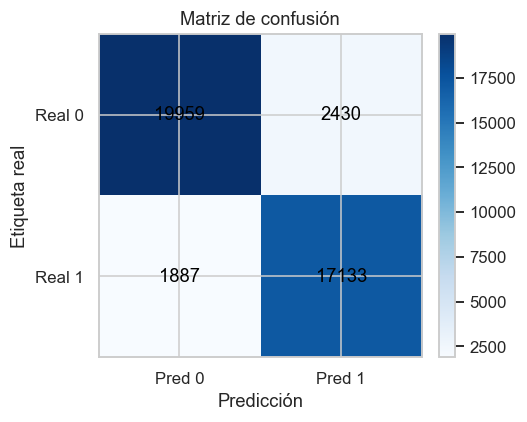

In [103]:
kNN_final = KNNClassifier(k=10, metric="euclidean", weighted=False)
kNN_final.fit(X_train, y_train)
final_predictions = kNN_final.predict(X_test)
final_probas = kNN_final.predict_proba(X_test)
cm = confusion_matrix(y_test, final_predictions)
acc = accuracy(y_test, final_predictions)
prec = precision(cm)
rec = recall(cm)
f1 = f1_score(cm)
auc = roc_auc(y_test, [p.get(1, 0.0) for p in final_probas])
print("Métricas finales en el set de test:")
print(f"  Accuracy : {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")
print(f"  F1-score : {f1:.4f}")
print(f"  AUC-ROC  : {auc:.4f}")
print("\nMatriz de confusión:")
cm_array = np.array([
    [cm["TN"], cm["FP"]],
    [cm["FN"], cm["TP"]]
])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_array, cmap="Blues")

for i in range(cm_array.shape[0]):
    for j in range(cm_array.shape[1]):
        ax.text(j, i, f"{cm_array[i, j]}", ha="center", va="center", color="black")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticklabels(["Real 0", "Real 1"])
ax.set_xlabel("Predicción")
ax.set_ylabel("Etiqueta real")
ax.set_title("Matriz de confusión")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### 5.5 Counterfactuals para trabajos no exitosos 

In [104]:
# 1) Feature names
feature_names = [
    "ReqCPUS", "ReqMem_MB", "ReqNodes", "ResvCPURAW",
    "TimelimitSec", "Priority", "submit_hour", "submit_dow",
    *PARTITION_GROUPS, *QOS_CATEGORIES
]

# 2) Filtrar failed — construir X_failed correctamente desde failed_pairs
y_test_arr   = np.array(list(y_test))
X_test_list  = list(X_test)

assert len(y_test_arr) == len(X_test_list), (
    f"Desalineación: y_test={len(y_test_arr)}, X_test={len(X_test_list)}"
)

X_failed = [x for x, y in zip(X_test_list, y_test_arr) if int(y) == 0]
print(f"Trabajos no completados en test: {len(X_failed)}")

# 3) Sampling
max_cases = min(1000, len(X_failed))
rng       = np.random.default_rng(42)
sample_idx = (
    rng.choice(len(X_failed), size=max_cases, replace=False)
    if len(X_failed) > max_cases
    else np.arange(len(X_failed))
)
X_failed_sample = [X_failed[i] for i in sample_idx]
print(f"Muestra seleccionada: {len(X_failed_sample)} casos")

# 4) Loop principal — counterfactuals (proba_before alineado aquí)
cf_results             = []
X_failed_cf            = []
proba_before           = []
pred_before            = []
skipped_already_target = 0

for x in X_failed_sample:
    res = generate_counterfactual(
        query=x,
        clf=kNN_final,
        feature_names=feature_names,
        scaler=scaler,
        target_class=1,
        max_iterations=80,
    )

    if res.get("already_target"):
        skipped_already_target += 1
        continue

    proba_before.append(res["proba_original"])
    pred_before.append(0)
    cf_results.append(res)
    X_failed_cf.append(res["counterfactual"] if res["found"] else x)

print(f"Casos descartados (ya eran target): {skipped_already_target}")
print(f"Casos procesados:                   {len(cf_results)}")

if len(cf_results) == 0:
    raise RuntimeError("No quedaron casos para analizar. Revisa el filtro o el modelo.")

# 5) Predicción después
pred_after  = [kNN_final.predict_one(x)                   for x in X_failed_cf]
proba_after = [kNN_final.predict_proba_one(x).get(1, 0.0) for x in X_failed_cf]

# Verificar alineación
assert len(proba_before) == len(proba_after) == len(cf_results), (
    f"Desalineación: proba_before={len(proba_before)}, "
    f"proba_after={len(proba_after)}, cf_results={len(cf_results)}"
)

# 6) Resumen
proba_before_arr = np.array(proba_before)
proba_after_arr  = np.array(proba_after)

baseline_completed_pred = sum(pred_before) / len(pred_before)
after_completed_pred    = sum(pred_after)  / len(pred_after)
avg_proba_gain          = float(np.mean(proba_after_arr - proba_before_arr))
found_rate              = sum(r["found"] for r in cf_results) / len(cf_results)

summary = pd.DataFrame({
    "Métrica": [
        "Muestra analizada (total)",
        "Descartados (modelo ya predice COMPLETED)",
        "Casos procesados",
        "Tasa predicha COMPLETED después",
        "Cambio absoluto en tasa",
        "Counterfactual encontrado",
        "Ganancia promedio P(COMPLETED)",
    ],
    "Valor": [
        len(X_failed_sample),
        skipped_already_target,
        len(cf_results),
        f"{after_completed_pred:.2%}",
        f"{(after_completed_pred - baseline_completed_pred):.2%}",
        f"{found_rate:.2%}",
        f"{avg_proba_gain:.4f}",
    ]
})
display(summary)

# 7) Top features modificadas
change_counter = {}
for r in cf_results:
    for ch in r["changes"]:
        change_counter[ch["feature"]] = change_counter.get(ch["feature"], 0) + 1

changes_df = (
    pd.DataFrame([
        {"feature": k, "count": v, "pct": v / len(cf_results) * 100}
        for k, v in change_counter.items()
    ])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
print("\nTop cambios sugeridos por los counterfactuals:")
display(changes_df.head(10))

# 8) Ejemplos interpretables
print("\nEjemplos de counterfactuals:")
for i in range(min(3, len(cf_results))):
    print(f"\n--- Caso {i+1} ---")
    print(explain(cf_results[i]))

Trabajos no completados en test: 22389
Muestra seleccionada: 1000 casos
Casos descartados (ya eran target): 212
Casos procesados:                   788


,Métrica,Valor
0,Muestra analizada (total),1000
1,Descartados (modelo ya predice COMPLETED),212
2,Casos procesados,788
3,Tasa predicha COMPLETED después,88.96%
4,Cambio absoluto en tasa,88.96%
5,Counterfactual encontrado,86.68%
6,Ganancia promedio P(COMPLETED),0.6225



Top cambios sugeridos por los counterfactuals:


,feature,count,pct
0,Priority,695,88.197970
1,ReqNodes,83,10.532995



Ejemplos de counterfactuals:

--- Caso 1 ---
Contrafactual: ENCONTRADO
P(COMPLETED): 0.00% → 50.00%

Cambios sugeridos:
  ▲ Priority        0  →  3254

--- Caso 2 ---
Contrafactual: ENCONTRADO
P(COMPLETED): 0.00% → 70.00%

Cambios sugeridos:
  ▲ Priority        0  →  6507

--- Caso 3 ---
Contrafactual: ENCONTRADO
P(COMPLETED): 0.00% → 50.00%

Cambios sugeridos:
  ▲ Priority        0  →  3254


### 5.6 Reason Codes


Jobs fallidos disponibles: 22389 | Analizando: 10


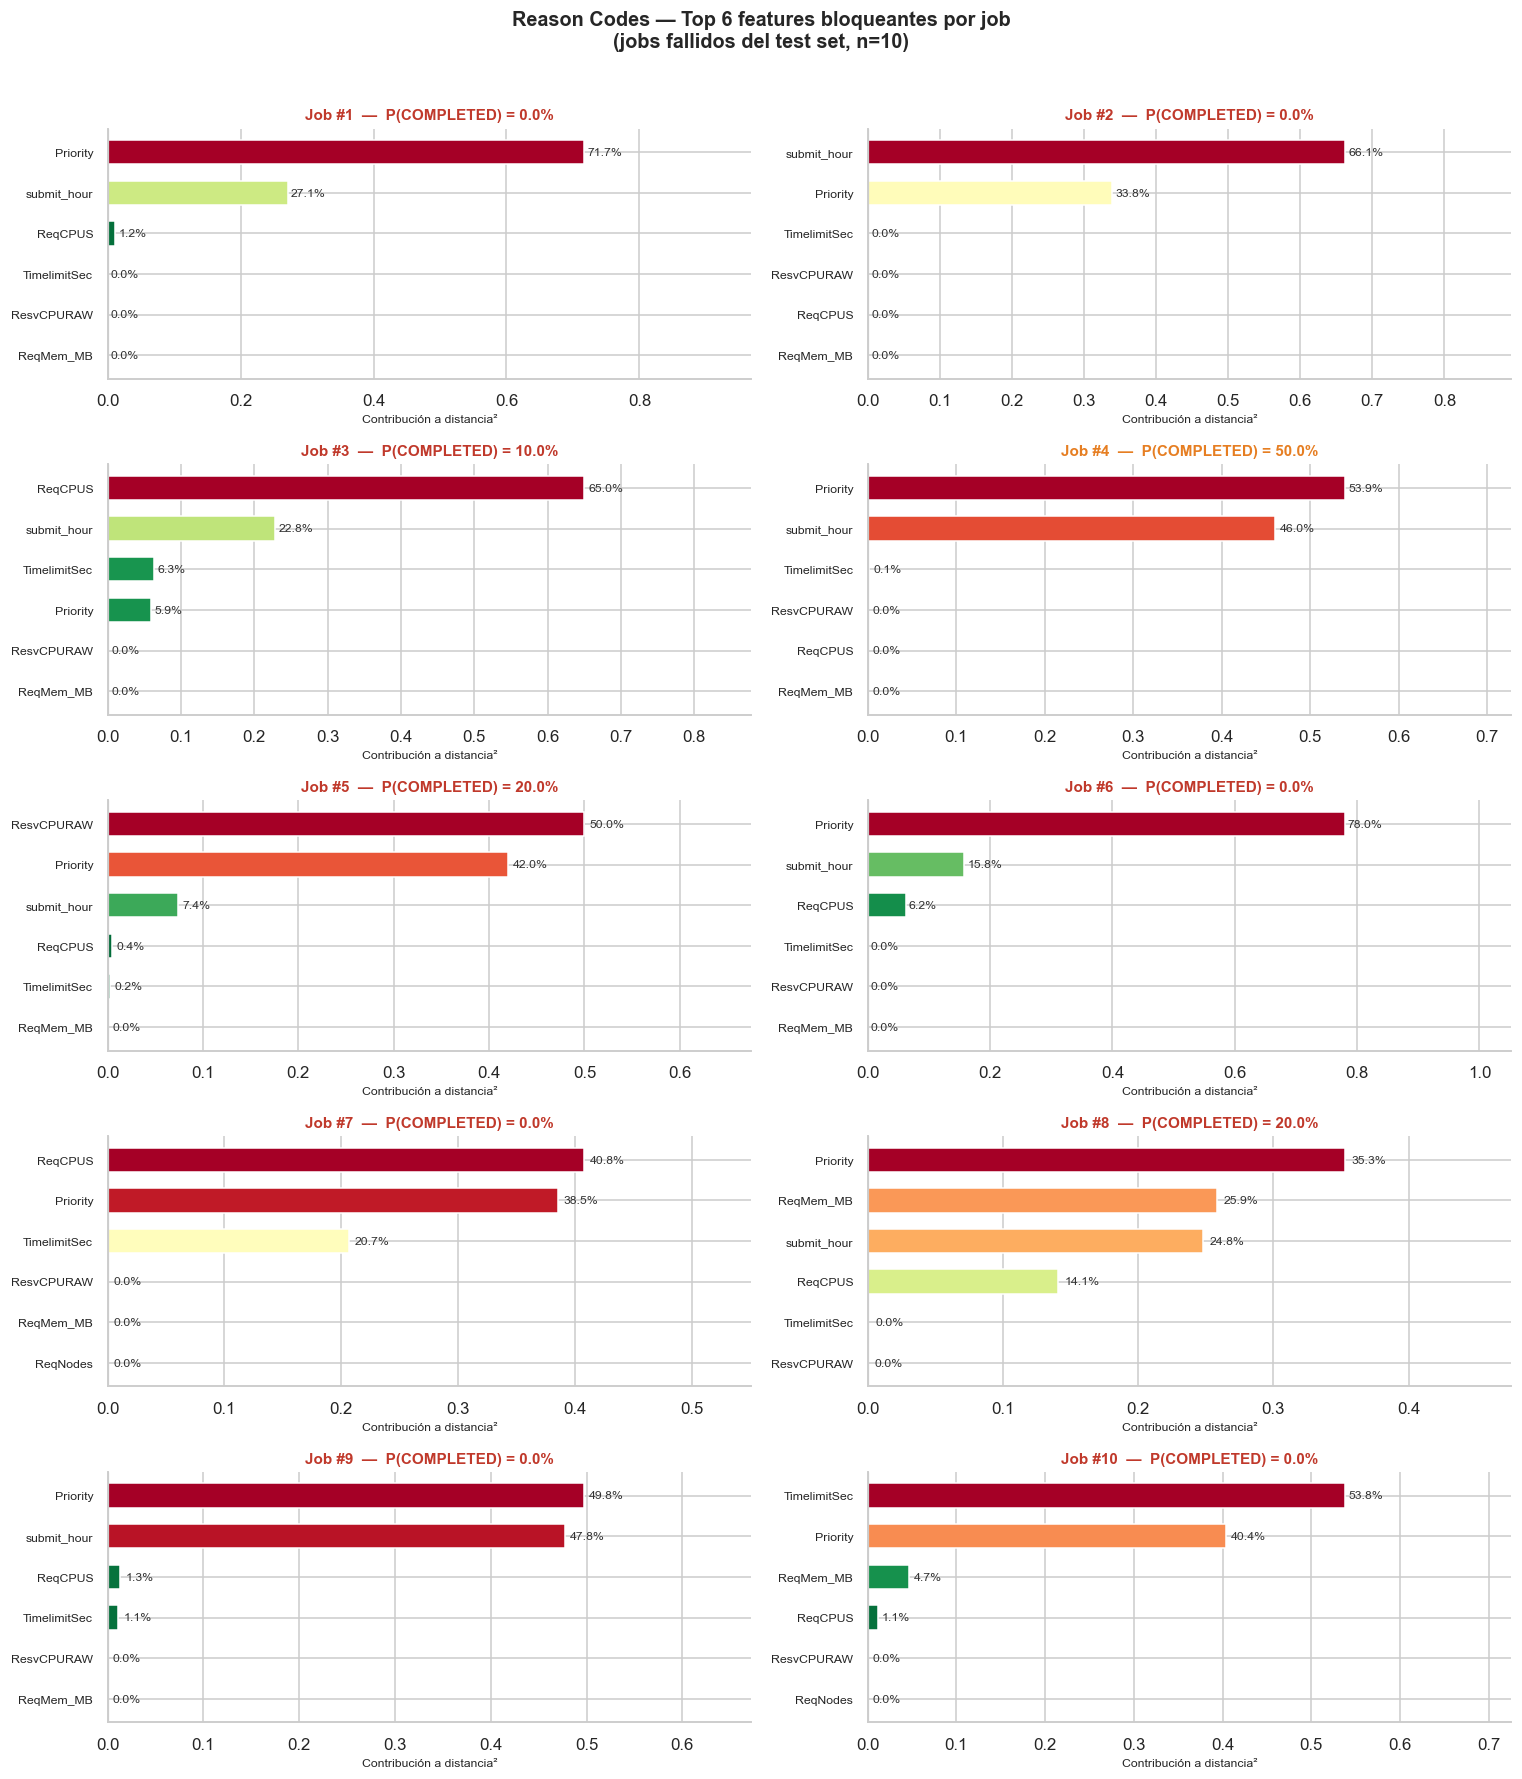

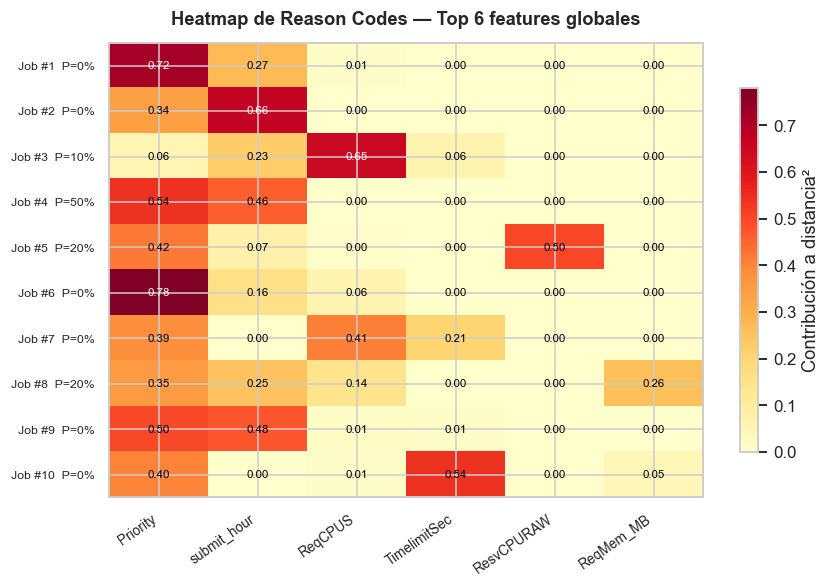

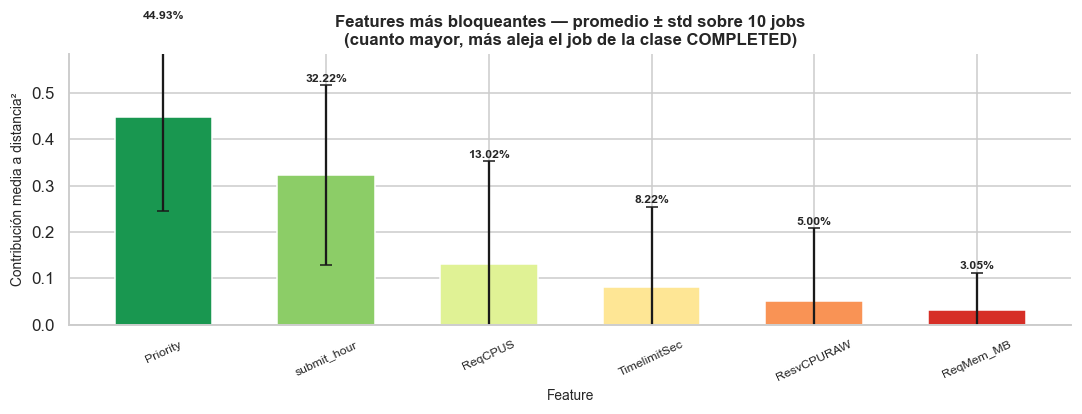

In [105]:
N_SAMPLES  = 10
TARGET_CLS = 1
TOP_N      = 6
SEED       = 42
CMAP_BAR   = "RdYlGn"   # rojo = muy bloqueante, verde = poco

feature_names = [
    "ReqCPUS", "ReqMem_MB", "ReqNodes", "ResvCPURAW",
    "TimelimitSec", "Priority", "submit_hour", "submit_dow",
    *PARTITION_GROUPS, *QOS_CATEGORIES
]

# 1) Muestra de jobs fallidos
y_arr    = np.array(list(y_test))
X_lst    = list(X_test)
X_failed = [x for x, y in zip(X_lst, y_arr) if int(y) == 0]

rng      = np.random.default_rng(SEED)
sample   = rng.choice(len(X_failed), size=min(N_SAMPLES, len(X_failed)), replace=False)
X_sample = [X_failed[i] for i in sample]

print(f"Jobs fallidos disponibles: {len(X_failed)} | Analizando: {len(X_sample)}")

# 2) Calcular reason codes para todos
all_rc    = []
all_proba = []

for x in X_sample:
    rc    = reason_codes(x, kNN_final, feature_names, target_class=TARGET_CLS)
    proba = kNN_final.predict_proba_one(x).get(TARGET_CLS, 0.0)
    all_rc.append(rc)
    all_proba.append(proba)

# ── Plot 1: Reason codes por job (subplots) ───────────────────
ncols = 2
nrows = int(np.ceil(len(X_sample) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.2))
axes = axes.flatten()

for job_idx, (rc, proba, ax) in enumerate(zip(all_rc, all_proba, axes)):
    names   = [n for n, _ in rc[:TOP_N]][::-1]
    contribs = [c for _, c in rc[:TOP_N]][::-1]

    # Color: rojo si contribución alta, verde si baja
    colors = plt.cm.RdYlGn_r(np.array(contribs) / max(contribs + [1e-6]))

    bars = ax.barh(names, contribs, color=colors, edgecolor="white", height=0.6)

    # Etiquetas en las barras
    for bar, val in zip(bars, contribs):
        ax.text(
            bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.1%}", va="center", ha="left", fontsize=8, color="#333"
        )

    ax.set_xlim(0, max(contribs) * 1.35)
    ax.set_title(
        f"Job #{job_idx + 1}  —  P(COMPLETED) = {proba:.1%}",
        fontsize=10, fontweight="bold",
        color="#c0392b" if proba < 0.3 else "#e67e22" if proba < 0.6 else "#27ae60"
    )
    ax.set_xlabel("Contribución a distancia²", fontsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.axvline(0, color="#ccc", linewidth=0.8)

# Ocultar axes sobrantes
for ax in axes[len(X_sample):]:
    ax.set_visible(False)

fig.suptitle(
    f"Reason Codes — Top {TOP_N} features bloqueantes por job\n"
    f"(jobs fallidos del test set, n={len(X_sample)})",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

# ── Plot 2: Heatmap — contribución por feature × job ─────────
# Construir matriz (jobs × features top globales)
top_global = (
    pd.DataFrame([
        {"feature": name, "contrib": contrib}
        for rc in all_rc for name, contrib in rc[:TOP_N]
    ])
    .groupby("feature")["contrib"]
    .mean()
    .sort_values(ascending=False)
    .head(TOP_N)
    .index.tolist()
)

matrix = np.zeros((len(X_sample), len(top_global)))
for i, rc in enumerate(all_rc):
    rc_map = dict(rc)
    for j, fname in enumerate(top_global):
        matrix[i, j] = rc_map.get(fname, 0.0)

fig, ax = plt.subplots(figsize=(max(8, len(top_global) * 1.1), max(4, len(X_sample) * 0.55)))
im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd", vmin=0, vmax=matrix.max())

ax.set_xticks(range(len(top_global)))
ax.set_xticklabels(top_global, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(X_sample)))
ax.set_yticklabels(
    [f"Job #{i+1}  P={p:.0%}" for i, p in enumerate(all_proba)],
    fontsize=8
)

# Valores en cada celda
for i in range(len(X_sample)):
    for j in range(len(top_global)):
        val = matrix[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7.5, color="black" if val < matrix.max() * 0.7 else "white")

plt.colorbar(im, ax=ax, label="Contribución a distancia²", shrink=0.8)
ax.set_title(
    f"Heatmap de Reason Codes — Top {TOP_N} features globales",
    fontsize=12, fontweight="bold", pad=12
)
plt.tight_layout()
plt.show()

# ── Plot 3: Barras apiladas — contribución agregada global ────
freq_df = (
    pd.DataFrame([
        {"feature": name, "contrib": contrib}
        for rc in all_rc for name, contrib in rc[:TOP_N]
    ])
    .groupby("feature")["contrib"]
    .agg(["mean", "std"])
    .sort_values("mean", ascending=False)
    .head(TOP_N)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
colors  = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(freq_df)))
bars    = ax.bar(freq_df["feature"], freq_df["mean"], color=colors,
                 yerr=freq_df["std"], capsize=4, edgecolor="white", width=0.6)

for bar, (_, row) in zip(bars, freq_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + row["std"] + 0.003,
        f"{row['mean']:.2%}", ha="center", va="bottom", fontsize=8, fontweight="bold"
    )

ax.set_ylabel("Contribución media a distancia²", fontsize=9)
ax.set_xlabel("Feature", fontsize=9)
ax.set_title(
    f"Features más bloqueantes — promedio ± std sobre {len(X_sample)} jobs\n"
    "(cuanto mayor, más aleja el job de la clase COMPLETED)",
    fontsize=11, fontweight="bold"
)
ax.tick_params(axis="x", rotation=25, labelsize=8)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, freq_df["mean"].max() * 1.3)
plt.tight_layout()
plt.show()

## 6. Deployment

### 6.1 Interpretación en contexto del dataset

El dataset utilizado corresponde a trabajos reales ejecutados en el cluster Kabre de CeNAT/CONARE durante 2024. A nivel bruto se analizaron `46,744` registros y, despues de la limpieza y construccion de variables, se trabajó con `42,745` muestras utilizables para el modelo. Esto hace que el problema tenga relevancia practica: no se trata de una simulacion academica, sino de un escenario operativo donde una mala configuracion puede consumir tiempo de investigacion y recursos de computo sin producir resultados utiles.

La distribucion de la variable objetivo muestra que el cluster enfrenta una tasa de exito limitada: aproximadamente `35.90%` de los trabajos terminan como `COMPLETED`, mientras que `52.06%` terminan como `FAILED`, ademas de casos `CANCELLED` y `TIMEOUT`. En este contexto, un modelo de apoyo previo al envio tiene valor porque permite identificar configuraciones de riesgo antes de ejecutar el trabajo.

Con las variables construidas a partir de CPUs solicitados, memoria, nodos, tiempo limite, prioridad, momento de envio, particion agrupada y QOS, el modelo final con `k=10` logra en el conjunto de prueba una `accuracy` de `0.8329`, `precision` de `0.7719`, `recall` de `0.8130`, `F1-score` de `0.7919` y `AUC-ROC` de `0.9187`. Estos resultados sugieren que la configuracion del trabajo si contiene informacion util para anticipar si un job se completara o no, aun cuando no sea posible garantizar el exito en todos los casos.

Desde la perspectiva de uso, la interpretacion mas valiosa del notebook no es solo la clasificacion binaria, sino la capacidad de actuar sobre ella. El analisis de contrafactuales muestra que, entre los casos estudiados, los cambios sugeridos con mayor frecuencia recaen sobre `Priority`, `ReqMem_MB` y en menor medida `ReqCPUS` y `ReqNodes`. Esto indica que, para trabajos historicamente parecidos, el modelo detecta patrones donde la asignacion de recursos y la politica de ejecucion influyen en la probabilidad de completar exitosamente el job.

Por tanto, en el contexto del dataset, el sistema puede interpretarse como una herramienta de diagnostico previo al envio: no reemplaza la experiencia del usuario ni las reglas del scheduler, pero si puede alertar sobre configuraciones riesgosas y proponer ajustes razonables antes de consumir tiempo de cola o recursos del cluster.

### 6.2 Limitaciones del modelo

Basado en el estudio del algoritmo y el contexto del problema actual, se determinó que las limitaciones principales del enfoque son las siguientes:

1. **Costo computacional:** El algoritmo kNN necesita comparar cada consulta con una gran cantidad de puntos del dataset, por lo que su costo crece con el numero de observaciones y de features. En este trabajo se usaron `42,745` muestras procesadas, lo cual vuelve costosa la evaluacion repetida del modelo, especialmente cuando se aplica validacion cruzada o se generan contrafactuales para muchos casos. Ademas, el enfoque lazy learning requiere conservar el conjunto de entrenamiento en memoria.

2. **Dependencia fuerte del preprocesamiento y de la representacion de variables:** El rendimiento de kNN depende directamente de como se define el espacio de caracteristicas. En este notebook fue necesario normalizar las variables numericas, agrupar particiones, convertir variables categoricas con one-hot encoding y transformar el problema en una etiqueta binaria. Si esta representacion cambia, el comportamiento del modelo tambien cambia. En otras palabras, el algoritmo no aprende una estructura abstracta; depende fuertemente de la definicion manual del vector de features.

3. **Pérdida de informacion por la formulacion binaria del problema:** Para simplificar la tarea de clasificacion, el notebook agrupa `FAILED`, `CANCELLED` y `TIMEOUT` en una sola clase negativa frente a `COMPLETED`. Esta decision facilita la implementacion, pero oculta diferencias importantes entre tipos de fallo. No es lo mismo un job cancelado manualmente que un job que excede el tiempo limite, y ambos casos podrian requerir recomendaciones distintas.

4. **Sensibilidad a desbalance de clases y a ruido local:** Aunque el desbalance no es extremo, la clase positiva sigue siendo minoritaria: solo alrededor de `35.90%` de los trabajos son `COMPLETED`, frente a una mayoria de casos no completados. Por eso, metricas como `accuracy` por si solas no bastan para juzgar el modelo y fue necesario revisar tambien `precision`, `recall`, `F1-score` y `AUC-ROC`. Ademas, como kNN toma decisiones a partir de vecinos cercanos, observaciones atipicas o zonas poco representadas del espacio pueden afectar la prediccion local.

5. **Las recomendaciones contrafactuales son sugerencias del modelo, no garantias causales:** El analisis de contrafactuales se apoya en la frontera de decision aprendida por kNN. Por ello, una recomendacion que aumente la probabilidad predicha de `COMPLETED` no garantiza que el trabajo realmente vaya a completarse en ejecucion real. De hecho, dentro de la muestra analizada de jobs no completados, `854` de `1000` casos ya eran clasificados por el modelo como `COMPLETED`, lo cual evidencia una discrepancia entre la salida del modelo y el resultado historico real en muchos ejemplos.

6. **Dificultad para definir un `k` adecuado y mantenerlo eficiente:** La seleccion de `k` influye directamente en el equilibrio entre sobreajuste y suavizado excesivo. En el notebook se mantiene el valor probado de `k=10`, pero cualquier ajuste futuro deberia reevaluarse cuidadosamente. Un `k` pequeno puede responder demasiado al ruido local, mientras que un `k` grande puede perder sensibilidad a patrones utiles. Ademas, buscar un `k` optimo mediante cross-validation agrega un costo computacional considerable.


### 6.3 Respuesta a las preguntas analíticas

La pregunta planteada fue si era posible predecir con precision razonable si un trabajo del cluster Kabre se completaria exitosamente y, en caso contrario, si se podian proponer cambios utiles en su configuracion. A partir de los resultados obtenidos, la respuesta es **si, de forma parcial y con utilidad practica**, aunque no absoluta.

Por un lado, el modelo logra un desempeño suficientemente bueno como para servir como herramienta de apoyo. Las metricas finales (`accuracy = 0.8329`, `F1-score = 0.7919`, `AUC-ROC = 0.9187`) muestran que existe una relacion clara entre la configuracion del trabajo y su probabilidad de terminar como `COMPLETED`. Esto significa que el historial del scheduler contiene patrones que kNN puede aprovechar para estimar riesgo antes de ejecutar un nuevo job.

Por otro lado, el componente de recomendaciones tambien aporta valor, pero debe interpretarse con cautela. En la muestra analizada de casos no completados, el procedimiento contrafactual encontro una alternativa valida en `33.56%` de los casos procesados, con una ganancia promedio de `0.1384` en la probabilidad estimada de `COMPLETED`, y una tasa predicha posterior de `36.99%`. Esto sugiere que, para una fraccion relevante de jobs problematicos, el modelo puede orientar ajustes concretos que mejoren la expectativa de exito.

Sin embargo, la respuesta no debe interpretarse como una promesa de exito automatico. El sistema funciona mejor como apoyo a la decision que como sustituto del criterio del usuario o de las politicas reales del cluster. En consecuencia, la conclusion final del notebook es que **si es posible construir un asistente predictivo y explicativo util para Kabre**, siempre que sus predicciones y recomendaciones se entiendan como apoyo operativo basado en evidencia historica, no como garantias deterministicas sobre el resultado de ejecucion.